In [1]:
from pathlib import Path
import yaml
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

## Pre-Process Data

In [2]:
#load config file
config_file = Path("config/config_model40k.yaml").read_text()
config = yaml.safe_load(config_file)

In [3]:
#set variables
data_directory = Path(config["dataset"]["data_dir"])
base_model_name = config["train_args"]["base_model_name"]
output_dir = Path(config["train_args"]["output_dir"])
train_batch_size = config["train_args"]["train_batch_size"]
eval_batch_size = config["train_args"]["eval_batch_size"]
document_column = config["train_args"]["document_column"]
summary_column = config["train_args"]["summary_column"]
num_workers = config["train_args"]["num_workers"]

In [4]:
#read in datasets
train_data = []
for url in config["dataset"]["train"]:
  train_data.append(pd.read_parquet(url))

val_data = []
for url in config["dataset"]["validation"]:
  val_data.append(pd.read_parquet(url))

In [5]:
#create training data
test_data = pd.concat(train_data, ignore_index=True)
test_data.to_csv(data_directory/"train_notclean_40k.csv", index=False)
#had to add this or the data didn't work
df = pd.read_csv(data_directory/"train_notclean_40k.csv", on_bad_lines='skip')
df.to_csv(data_directory/"train_40k.csv", index=False)
df.head()

,article,abstract
0,additive models @xcite provide an important fa...,additive models play an important role in semi...
1,the leptonic decays of a charged pseudoscalar ...,"we have studied the leptonic decay @xmath0 , v..."
2,the transport properties of nonlinear non - eq...,"in 84 , 258 ( 2000 ) , mateos conjectured that..."
3,studies of laser beams propagating through tur...,the effect of a random phase diffuser on fluct...
4,the so - called `` nucleon spin crisis '' rais...,with a special intention of clarifying the und...


In [6]:
#create validation data
df = pd.concat(val_data, ignore_index=True)
df.to_csv(data_directory/"val_40k.csv", index=False)
df.head()

,article,abstract
0,we examine the regularization scheme dependenc...,we calculate the triviality bound on the higgs...
1,the `` cross '' term for the identical particl...,we study the effect of final state interaction...
2,a cooper - pair condensate in a superconductor...,we examine the depairing field @xmath0 of non ...
3,let @xmath3 be a finite dimensional basic alge...,the aim of this paper is to introduce @xmath0-...
4,cosmological cold dark matter ( cdm ) simula...,we present flux - ratio curves of the _ fold a...


## Create/Train Model

In [ ]:
#nltk download fixes error during validation
import nltk
nltk.download('punkt_tab')

!python summarization/run_summarization.py \
     --model_name_or_path {base_model_name} \
     --do_train \
     --do_eval \
     --train_file {data_directory}/train_40k.csv \
     --validation_file {data_directory}/val_40k.csv \
     --output_dir {output_dir} \
     --per_device_train_batch_size={train_batch_size} \
     --per_device_eval_batch_size={eval_batch_size} \
     --predict_with_generate \
     --text_column {document_column} \
     --summary_column {summary_column} \
     --preprocessing_num_workers={num_workers}

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Corinne\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


^C


## Load Model and Test

In [14]:
config_file = Path("config/config_model40k.yaml").read_text()
config = yaml.safe_load(config_file)
bart_model = config["train_args"]["base_model_name"]
model_name = config["model"]["model_name"]

#### Load Model

In [12]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

c:\Users\Corinne\Documents\MSAI\CMPE-252\CMPE-252-summary-project\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Please make sure the generation config includes `forced_bos_token_id=0`. 
Loading weights: 100%|██████████| 512/512 [00:00<00:00, 1676.21it/s]


#### Summary Test

In [13]:
text = "Bats (order Chiroptera /kaɪˈrɒptərə/) are winged mammals; the only mammals capable of true and sustained flight. Bats are more agile in flight than most birds, flying with their long spread-out digits covered with a thin membrane or patagium. The smallest bat, and one of the smallest extant mammals, is Kitti's hog-nosed bat, which is 29–33 mm (1.1–1.3 in) in length, 150 mm (5.9 in) across the forearm and 2 g (0.071 oz) in mass. The largest bats are the flying foxes, with the giant golden-crowned flying fox (Acerodon jubatus) reaching a weight of 1.5 kg (3.3 lb) and having a wingspan of 1.6 m (5 ft 3 in)."
inputs = tokenizer(text, return_tensors="pt")

outputs = model.generate(**inputs, max_new_tokens=100)
summary = tokenizer.decode(outputs[0], skip_special_tokens=True)

print(summary)

Both `max_new_tokens` (=100) and `max_length`(=142) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


we report the discovery of a new bat species , the giant golden - crowned flying fox ( acerodon jubatus ) , which is the smallest bat known to date . 
 this bat , which has a wingspan of 1.6 m ( 5 ft 3 in ) , is one of the smallest extant mammals , and one of only a handful of bat species known to be capable of true sustained flight .    in this paper , we report on the


#### Compare with BART

In [16]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

bart_tokenizer = AutoTokenizer.from_pretrained(bart_model)
bart_model = AutoModelForSeq2SeqLM.from_pretrained(bart_model)

bart_inputs = bart_tokenizer(text, return_tensors="pt")
bart_outputs = bart_model.generate(**bart_inputs, max_new_tokens=100)
summary = bart_tokenizer.decode(bart_outputs[0], skip_special_tokens=True)

print(summary)



Loading weights: 100%|██████████| 511/511 [00:00<00:00, 1474.26it/s]
Both `max_new_tokens` (=100) and `max_length`(=142) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Bats are the only mammals capable of true and sustained flight. Kitti's hog-nosed bat is 29–33 mm (1.1–1.3 in) in length, 150 mm (5.9 in) across the forearm and 2 g (0.071 oz) in mass. The largest bats are the flying foxes, with the giant golden-crowned flying fox (Acerodon jubatus) reaching a weight of 1.5 kg


## Cross Attentions

##### Token-Level Cross Attention

In [7]:
config_file = Path("config/config_model40k.yaml").read_text()
config = yaml.safe_load(config_file)
model_name = config["model"]["model_name"]
input_document = config["cross_attentions_heatmap"]["input_document"]
summary_size = config["cross_attentions_heatmap"]["summary_size"]
plot_color_scheme = config["cross_attentions_heatmap"]["plot_color_scheme"]

In [8]:
#load model, set as 'eager' and put into eval mode for cross attentions
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name, attn_implementation="eager")
model.eval()

c:\Users\Corinne\Documents\MSAI\CMPE-252\CMPE-252-summary-project\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Please make sure the generation config includes `forced_bos_token_id=0`. 
Loading weights: 100%|██████████| 512/512 [00:00<00:00, 2711.93it/s]


BartForConditionalGeneration(
  (model): BartModel(
    (shared): BartScaledWordEmbedding(50265, 1024, padding_idx=1)
    (encoder): BartEncoder(
      (embed_tokens): BartScaledWordEmbedding(50265, 1024, padding_idx=1)
      (embed_positions): BartLearnedPositionalEmbedding(1026, 1024)
      (layers): ModuleList(
        (0-11): 12 x BartEncoderLayer(
          (self_attn): BartAttention(
            (k_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (v_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (q_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
          )
          (self_attn_layer_norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=1024, out_features=4096, bias=True)
          (fc2): Linear(in_features=4096, out_features=1024, bias=True)
        

In [9]:
model.config

BartConfig {
  "_num_labels": 3,
  "activation_dropout": 0.0,
  "activation_function": "gelu",
  "add_final_layer_norm": false,
  "architectures": [
    "BartForConditionalGeneration"
  ],
  "attention_dropout": 0.0,
  "bos_token_id": 0,
  "classif_dropout": 0.0,
  "classifier_dropout": 0.0,
  "d_model": 1024,
  "decoder_attention_heads": 16,
  "decoder_ffn_dim": 4096,
  "decoder_layerdrop": 0.0,
  "decoder_layers": 12,
  "decoder_start_token_id": 2,
  "dropout": 0.1,
  "dtype": "float32",
  "encoder_attention_heads": 16,
  "encoder_ffn_dim": 4096,
  "encoder_layerdrop": 0.0,
  "encoder_layers": 12,
  "eos_token_id": 2,
  "force_bos_token_to_be_generated": true,
  "gradient_checkpointing": false,
  "id2label": {
    "0": "LABEL_0",
    "1": "LABEL_1",
    "2": "LABEL_2"
  },
  "init_std": 0.02,
  "is_decoder": false,
  "is_encoder_decoder": true,
  "label2id": {
    "LABEL_0": 0,
    "LABEL_1": 1,
    "LABEL_2": 2
  },
  "max_position_embeddings": 1024,
  "model_type": "bart",
  "norma

In [10]:
#tokenize short input text
inputs = tokenizer(input_document, return_tensors="pt", truncation=True, max_length=1024)

In [11]:
#find cross attentions
with torch.no_grad():
    outputs = model.generate(
        **inputs,
        output_attentions=True,
        return_dict_in_generate=True,
        max_new_tokens=summary_size
    )

cross_attentions = outputs.cross_attentions
cross_attentions

Both `max_new_tokens` (=20) and `max_length`(=142) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
c:\Users\Corinne\Documents\MSAI\CMPE-252\CMPE-252-summary-project\.venv\lib\site-packages\transformers\generation\utils.py:1575: UserWarning: Unfeasible length constraints: `min_length` (56) is larger than the maximum possible length (21). Generation will stop at the defined maximum length. You should decrease the minimum length and/or increase the maximum length.
  warnings.warn(


((tensor([[[[4.4028e-01, 4.1221e-06, 4.9524e-06,  ..., 2.1374e-01,
             2.2868e-05, 1.2304e-01]],
  
           [[1.5792e-01, 3.5946e-03, 6.7820e-03,  ..., 3.0870e-01,
             1.3631e-03, 5.8248e-02]],
  
           [[1.6414e-01, 1.2502e-02, 2.0237e-02,  ..., 1.1280e-01,
             6.0611e-03, 1.8552e-01]],
  
           ...,
  
           [[1.8803e-01, 2.2314e-03, 5.2037e-04,  ..., 2.3407e-03,
             3.1374e-03, 7.3461e-01]],
  
           [[2.9680e-02, 6.0732e-03, 7.9165e-05,  ..., 1.6650e-02,
             4.1116e-03, 5.5338e-02]],
  
           [[1.3899e-01, 1.8273e-04, 4.3376e-04,  ..., 8.9750e-02,
             5.4732e-02, 1.0751e-01]]],
  
  
          [[[4.4028e-01, 4.1221e-06, 4.9524e-06,  ..., 2.1374e-01,
             2.2868e-05, 1.2304e-01]],
  
           [[1.5792e-01, 3.5946e-03, 6.7820e-03,  ..., 3.0870e-01,
             1.3631e-03, 5.8248e-02]],
  
           [[1.6414e-01, 1.2502e-02, 2.0237e-02,  ..., 1.1280e-01,
             6.0611e-03, 1.8552e-01]],

In [12]:
#labels for the heat map
#get the input token ids and use tokenizer to convert to text
input_ids = inputs["input_ids"][0]
input_tokens = tokenizer.convert_ids_to_tokens(input_ids)
input_tokens_clean = [token.replace("Ġ", "") for token in input_tokens]

#get the output token ids and use tokenizer to convert to text
output_ids = outputs.sequences[0]
output_tokens = tokenizer.convert_ids_to_tokens(output_ids)
output_tokens_clean = [token.replace("Ġ", "") for token in output_tokens]

In [13]:
#for each output token, average the attention across all heads in the last layer
attention_matrix = []
for cross_attention in cross_attentions:
    cross_attention = cross_attention[-1]
    cross_attention = cross_attention.squeeze()
    attention_score = cross_attention.mean(dim=(0, 1)) 
    attention_matrix.append(attention_score.numpy())

#matrix of output token row, input token columns
attention_matrix = np.array(attention_matrix)
attention_matrix

array([[0.10502943, 0.02901032, 0.02097418, ..., 0.24207729, 0.01834571,
        0.04938458],
       [0.10502943, 0.02901031, 0.02097417, ..., 0.2420773 , 0.01834571,
        0.04938458],
       [0.07463539, 0.01112573, 0.02322275, ..., 0.28785416, 0.00659085,
        0.02991755],
       ...,
       [0.04327003, 0.00823579, 0.03773369, ..., 0.17169264, 0.0286339 ,
        0.02168283],
       [0.04304868, 0.00471846, 0.02239827, ..., 0.24720713, 0.00346923,
        0.02492088],
       [0.03635606, 0.00361218, 0.01726345, ..., 0.24605376, 0.00117838,
        0.02040323]], shape=(20, 55), dtype=float32)

In [14]:
#remove input tokens that are too influential, or punctuation
tokens_to_remove = ['<s>', '</s>', '.', ';', 'Ċ', "\n", ""]

filtered = []
for i, token in enumerate(input_tokens_clean):
    if token not in tokens_to_remove:
        filtered.append(i)

filtered_attention_matrix = attention_matrix[:, filtered]
filtered_input_tokens = [input_tokens_clean[i] for i in filtered]

#remove out tokens that are too influential, or punctuation
filtered_output = []
for i, token in enumerate(output_tokens_clean):
    if token not in tokens_to_remove:
        filtered_output.append(i)

filtered_attention_matrix = filtered_attention_matrix[filtered_output, :]
filtered_output_tokens = [output_tokens_clean[i] for i in filtered_output]

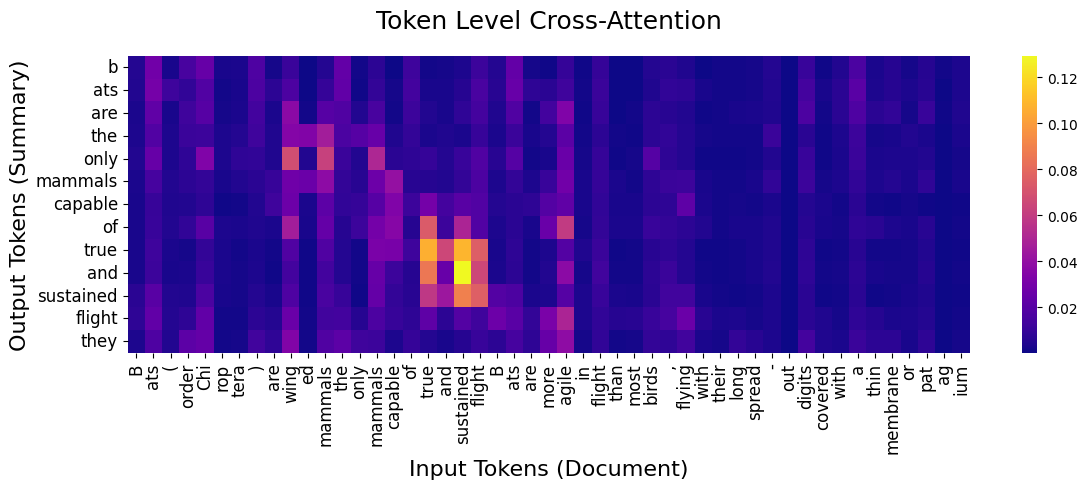

In [15]:
#visualize data
fig, ax = plt.subplots(figsize=(12, 5))

sns.heatmap(
    filtered_attention_matrix,
    xticklabels=filtered_input_tokens,
    yticklabels=filtered_output_tokens,
    cmap=plot_color_scheme,
    ax=ax
)

ax.set_xlabel("Input Tokens (Document)", fontsize=16)
ax.set_ylabel("Output Tokens (Summary)", fontsize=16)
ax.set_title("Token Level Cross-Attention", fontsize=18, pad=20)

plt.xticks(rotation=90, fontsize=12)
plt.yticks(rotation=0, fontsize=12)
plt.tight_layout()
plt.savefig("cross_attentions_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()